# Trilha 1: NMR (Nuclear Magnetic Resonance)

Neste notebook, tratamos o problema da trilha 1, com pré-processamento, dois métodos de resolução -- uma MLP e uma PINN -- e concluímos com um simples ensembling

### Importação dos pacotes

In [1]:
# Manipulação, plots
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import datetime 

# pré-processamento
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from scipy.special import erfcx
import pywt

# Rede neural
import torch
import torch.nn as nn

In [81]:
## definindo seed
seed = 765
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

### Carregando e limpando dados

Dados de teste e treino formatados diferentemente nos quesitos: correção de string, clipagem em zero e normalização

In [5]:
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../../RMN/train/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    # corrigindo string
    temp_df.T2_data = temp_df.T2_data.str.replace(",",".")
    temp_df.T2_data = temp_df.T2_data.str.replace(" ","").astype(float)
    # clipando em zero 
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    array = np.vstack((array,temp_df.T2_data))

train_df = pd.DataFrame(array)
train_df['y'] = pd.read_csv("../../RMN/train/Output/OilSat.csv", sep="\t")['Oil_Sat']

array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../../RMN/test/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #dado de test não requer correção de string nem clipar
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    array = np.vstack((array,temp_df.T2_data))
test_df = pd.DataFrame(array)

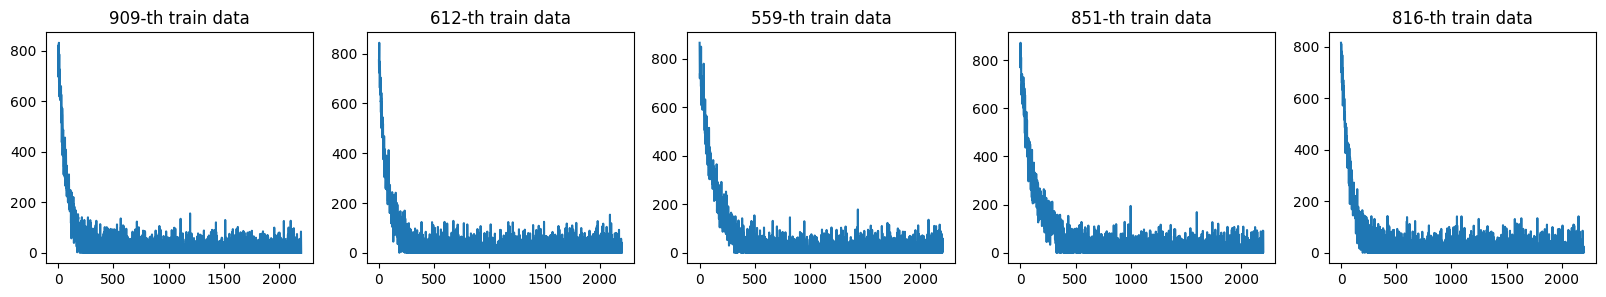

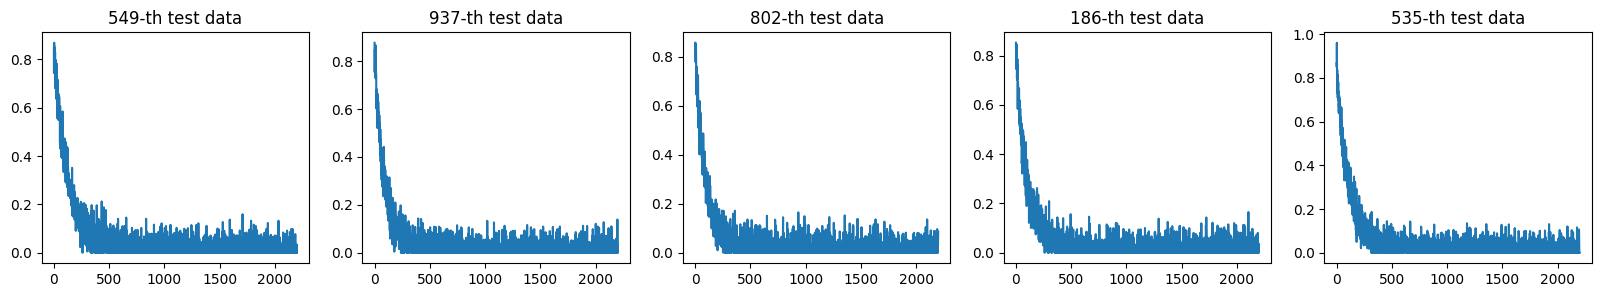

In [7]:
'''Plot graph of test and train after clip for comparison'''
fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data")
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th test data")
plt.show();

Suavização baseada em wavelets (DWT, discrete wavelet transform). Levemente melhor que filtro Savitzky-Golay no resultado final.

In [5]:
def DWTdenoise(noisy, wvlet='db6', level=6, mode='soft'):
    # decomposição
    coeffs = pywt.wavedec(noisy, wvlet, level=level)#, mode='smooth')
    cA, cD = coeffs[0], coeffs[1:]

    # Nível de ruído (estimativa)
    sigma = np.median(np.abs(cD[-1])) / 0.6745 *2
    T = sigma * np.sqrt(2 * np.log(len(noisy)))

    # Thresholding e retorna sinal reconstruído
    coeffs_thresh = [cA] + [pywt.threshold(cd, T, mode=mode) for cd in cD]
    return pywt.waverec(coeffs_thresh, wvlet), coeffs_thresh

Normalizando ponto inicial após suavizar

In [9]:
scaler = sklearn.preprocessing.MinMaxcaler()


array = np.array(train_df.drop('y',axis=1))
DWT_array = np.zeros((0,2202))
for i in range(len(train_df)):
    # Aplicando o denoising
    row,_ = DWTdenoise(array[i], 'db6', level=6)
    DWT_array = np.vstack((DWT_array,row))
#normalizar
DWT_array = scaler.fit_transform(DWT_array.T).T
train_DWT_df = pd.DataFrame(DWT_array)
train_DWT_df['y'] = train_df['y'].copy()

array = np.array(test_df)
DWT_array = np.zeros((0,2202))
for i in range(len(test_df)):
    # Aplicando o denoising
    row,_ = DWTdenoise(array[i], 'db6', level=6)
    DWT_array = np.vstack((DWT_array,row))
#normalizar
DWT_array = scaler.fit_transform(DWT_array.T).T
test_DWT_df = pd.DataFrame(DWT_array)

train_DWT_df.shape, test_DWT_df.shape

((1000, 2203), (1000, 2202))

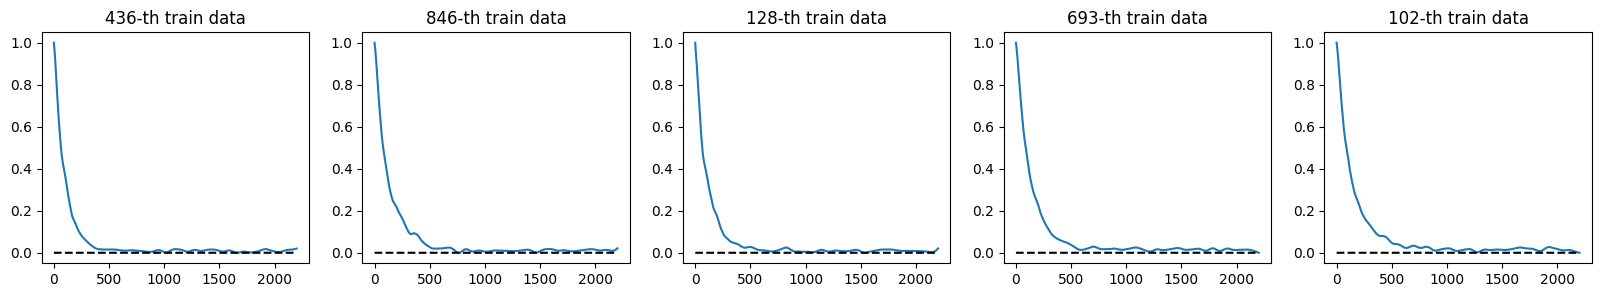

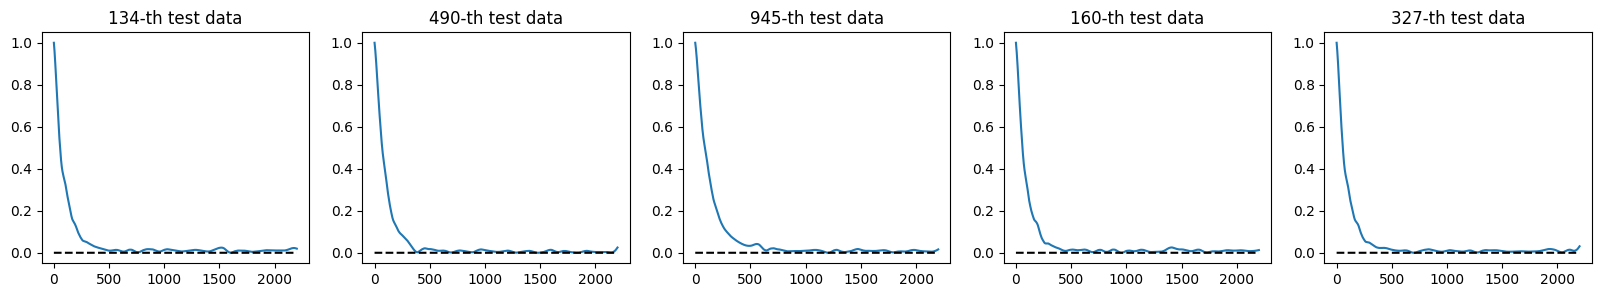

In [10]:
### Plotando amostragem da versão suavizada do dados
fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_DWT_df.iloc[j,:-1].values)
    ax[i].set_title(f"{j}-th train data")
    ax[i].plot([0]*train_DWT_df.shape[1],'k--')
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_DWT_df .loc[j].values)
    ax[i].set_title(f"{j}-th test data")
    ax[i].plot([0]*test_DWT_df.shape[1],'k--')
plt.show();

In [11]:
train_DWT_df = train_DWT_df.iloc[:,:700]
train_DWT_df['y'] = train_df['y']
train_DWT_df.to_csv('data/data_train_denoised.csv', sep='\t', index=False)

test_DWT_df  = test_DWT_df.iloc[:,:700]
test_DWT_df.to_csv('data/data_test_denoised.csv', sep='\t', index=False)

Fazendo PCA, que será usado para o método MLP

In [15]:
pca = sklearn.decomposition.PCA(n_components=.999)
pca.fit(train_DWT_df.iloc[:,:-1])

,n_components,0.999
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [17]:
train_df_pca = pd.DataFrame(pca.transform(train_DWT_df.iloc[:,:-1]))
train_df_pca['y'] = train_DWT_df['y']
test_df_pca = pd.DataFrame(pca.transform(test_DWT_df))

### Treinamento

Partição fixa para ensembling posterior

In [83]:
n = len(train_DWT_df)
n_train = int(0.8 * n)

indices = np.arange(n)
np.random.shuffle(indices)

indx_train = indices[:n_train]
indx_val   = indices[n_train:]

#### Modelo MLP

In [84]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df_pca.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_df_pca['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs = Subset(dataset, indx_train)
valDs   = Subset(dataset, indx_val)

val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)

Device is cuda


In [137]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)


criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.056731 | Val MSE: 0.044184
Epoch 05 | Train MSE: 0.033070 | Val MSE: 0.029003
Epoch 10 | Train MSE: 0.015310 | Val MSE: 0.012716
Epoch 15 | Train MSE: 0.013036 | Val MSE: 0.011377
Epoch 20 | Train MSE: 0.012433 | Val MSE: 0.010891
Epoch 25 | Train MSE: 0.011339 | Val MSE: 0.009515
Epoch 30 | Train MSE: 0.011937 | Val MSE: 0.013061
Epoch 35 | Train MSE: 0.010548 | Val MSE: 0.009343


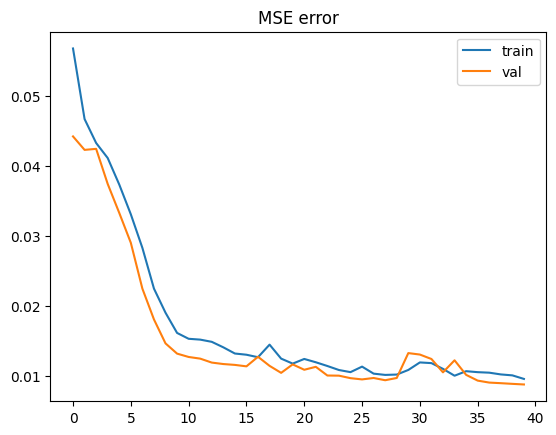

RMSE: 0.09376093 R²: 0.8332565 MAE: 0.072770774


In [138]:
epochs = 40
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval_MLP = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval_MLP)**2)
mae = np.mean(np.abs((y_pred - yval_MLP)))
R2  = 1- mse/np.std(yval_MLP)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

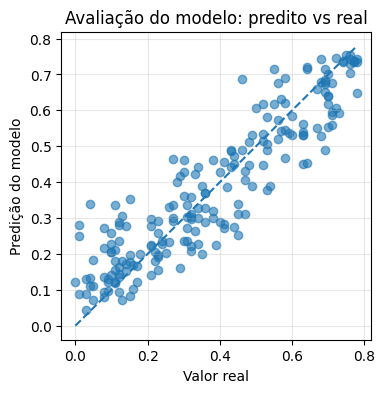

In [143]:
# Gráfico de avaliação
plt.figure(figsize=(4, 4))
plt.scatter(yval,y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Valor real")
plt.ylabel("Predição do modelo")
plt.title("Avaliação do modelo: predito vs real")
plt.grid(True, alpha=0.3)
plt.show()

In [89]:
Xtest = torch.Tensor(np.array(test_df_pca)).to(device)
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

## Salvando resultados
output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
output_df['%'] = ytest_pred
output_df.to_csv("submission/time2_trilha1_pred_MLP.csv", sep="\t", index=False)
print("csv saved");

csv saved


#### PINN

O método inspirado em física se baseia em uma função bi-exponencial de forma
$$f(t) = A_o e^{-t/T_{2,o}} + A_w e^{-t/T_{2,w}} . $$
A rede neural tem como saída 4 parâmetros, para poder representar os 4 parâmetros da função acima, $A_o$ $A_w$ $T_{2,o}$ $T_{2,w}$ ($o$ para óleo, $w$ para água). A função de erro tem duas contribuições: uma é o fator $A_o/(A_o+A_w)$, a ser comparado com o output $y$ tradicional (erro de output); a outra utiliza os quatro parâmetros para reconstruir a função $f(t)$ acima, e a compara com a curva de entrada do modelo, $x$ (erro de fit).

In [140]:
X = torch.Tensor(np.array(train_DWT_df.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_DWT_df['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs = Subset(dataset, indx_train)
valDs   = Subset(dataset, indx_val)

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [111]:
headlessmodel = nn.Sequential(
    nn.Linear(X.shape[1],128),
    nn.ReLU(),
    nn.Linear(128,32),
    nn.ReLU(),
    nn.Linear(32,4), #interpreted as A_o, A_w, T2_o, T2_w
    ).to(device)

optimizer = torch.optim.Adam(headlessmodel.parameters(), lr=1e-3)

Epoch 00 | train output MSE: 0.055864 | train fit MSE: 0.074885 | val output MSE: 0.047669 | val fit MSE: 0.076479
Epoch 10 | train output MSE: 0.039585 | train fit MSE: 0.054129 | val output MSE: 0.038609 | val fit MSE: 0.050611
Epoch 20 | train output MSE: 0.021338 | train fit MSE: 0.004914 | val output MSE: 0.019997 | val fit MSE: 0.004009
Epoch 30 | train output MSE: 0.014514 | train fit MSE: 0.000472 | val output MSE: 0.013521 | val fit MSE: 0.000411
Epoch 40 | train output MSE: 0.013271 | train fit MSE: 0.000261 | val output MSE: 0.011025 | val fit MSE: 0.000249
Epoch 50 | train output MSE: 0.011382 | train fit MSE: 0.000244 | val output MSE: 0.010178 | val fit MSE: 0.000237
Epoch 60 | train output MSE: 0.010863 | train fit MSE: 0.000251 | val output MSE: 0.009641 | val fit MSE: 0.000239
Epoch 70 | train output MSE: 0.010540 | train fit MSE: 0.000253 | val output MSE: 0.010124 | val fit MSE: 0.000273
Epoch 80 | train output MSE: 0.011383 | train fit MSE: 0.000272 | val output MSE

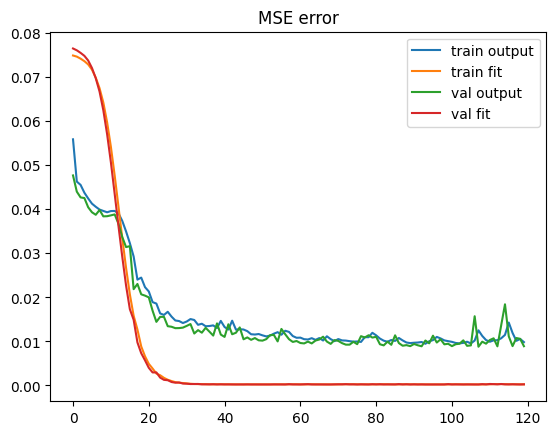

In [112]:
epochs = 120
history = []
for epoch in range(epochs):
    headlessmodel.train()
    train_loss_output, train_loss_phys = 0., 0.

    for xb, yb in train_loader:
        pre_outcome = headlessmodel(xb)
        #funções de ativação diferentes devido aos diferentes valores dos parâmetros
        outp1 = nn.Sigmoid()(pre_outcome[:,:2])
        outp2 = nn.functional.softplus(pre_outcome[:,2:]) #versão mais suave do ReLU para reduzir instabilidade
        outcome = torch.cat([outp1,outp2],dim=1)
        outcome_ext = outcome.unsqueeze(1).expand(*xb.shape,outcome.shape[-1])
        
        t_values = torch.arange(0,xb.shape[1]).unsqueeze(0).expand(xb.shape).to(device)
        loss_output = nn.MSELoss()(outcome[:,0]/(outcome[:,0]+outcome[:,1]),yb.squeeze())
        loss_phys   = nn.MSELoss()(xb,
                            outcome_ext[:,:,0]*torch.exp(-t_values/torch.clamp(outcome_ext[:,:,2], min=1e-3)) + \
                            outcome_ext[:,:,1]*torch.exp(-t_values/torch.clamp(outcome_ext[:,:,3], min=1e-3))) 

        optimizer.zero_grad()
        (loss_output+4*loss_phys).backward()
        optimizer.step()

        train_loss_output += loss_output.item() * xb.size(0)
        train_loss_phys += loss_phys.item() * xb.size(0)
    train_loss_output /=len(train_loader.dataset)
    train_loss_phys /=len(train_loader.dataset)

    headlessmodel.eval()
    val_loss_output, val_loss_phys = 0., 0.
    with torch.no_grad():
        for xb, yb in val_loader:
            pre_outcome = headlessmodel(xb)
            outp1 = nn.Sigmoid()(pre_outcome[:,:2])
            outp2 = nn.functional.softplus(pre_outcome[:,2:])
            outcome = torch.cat([outp1,outp2],dim=1)
            outcome_ext = outcome.unsqueeze(1).expand(*xb.shape,outcome.shape[-1])

            t_values = torch.arange(0,xb.shape[1]).unsqueeze(0).expand(xb.shape).to(device)
            loss_output = nn.MSELoss()(outcome[:,0]/(outcome[:,0]+outcome[:,1]),yb.squeeze())
            loss_phys   = nn.MSELoss()(xb,
                            outcome_ext[:,:,0]*torch.exp(-t_values/torch.clamp(outcome_ext[:,:,2], min=1e-3)) + \
                            outcome_ext[:,:,1]*torch.exp(-t_values/torch.clamp(outcome_ext[:,:,3], min=1e-3))) 
                                          
            val_loss_output += loss_output.item() * xb.size(0)
            val_loss_phys += loss_phys.item() * xb.size(0)
        val_loss_output /=len(val_loader.dataset)
        val_loss_phys /=len(val_loader.dataset)

    history.append((train_loss_output, train_loss_phys,val_loss_output, val_loss_phys))

    if epoch%10==0: print(f"Epoch {epoch:02d} | train output MSE: {train_loss_output:.6f} | train fit MSE: {train_loss_phys:.6f}",
                        f"| val output MSE: {val_loss_output:.6f} | val fit MSE: {val_loss_phys:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train output')
plt.plot(range(len(history)), [l[1] for l in history], label='train fit')
plt.plot(range(len(history)), [l[2] for l in history], label='val output')
plt.plot(range(len(history)), [l[3] for l in history], label='val fit')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.09443201 R²: 0.83086103


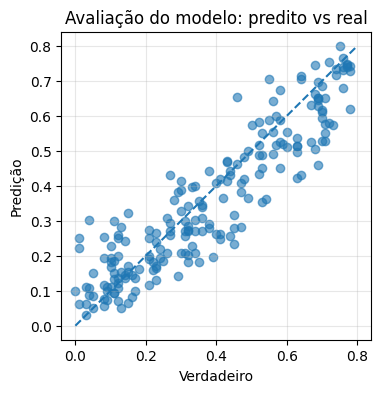

In [159]:
Xval = valDs.dataset.tensors[0][valDs.indices]
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

headlessmodel.eval()
with torch.no_grad():
    pre_outcome_val = headlessmodel(Xval)
    outp1_val = nn.Sigmoid()(pre_outcome_val[:,:2])
    outp2_val = nn.functional.softplus(pre_outcome_val[:,2:])
    y_param_pred = torch.cat([outp1_val,outp2_val],dim=1).squeeze().detach().cpu().numpy()
 
y_predPINN = y_param_pred[:,0]/(y_param_pred[:,0]+y_param_pred[:,1])

# RMSE, R2
mse = np.mean((y_predPINN-yval)**2)
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2)

plt.figure(figsize=(4,4))
plt.scatter(yval, y_predPINN, alpha=0.6)
plt.plot([0, .8], [0, .8], '--')

plt.ylabel("Predição");plt.xlabel("Verdadeiro");plt.title(f"Avaliação do modelo: predito vs real");
plt.grid(True, alpha=0.3);plt.show()

Exemplo de como o método gera um fit da função

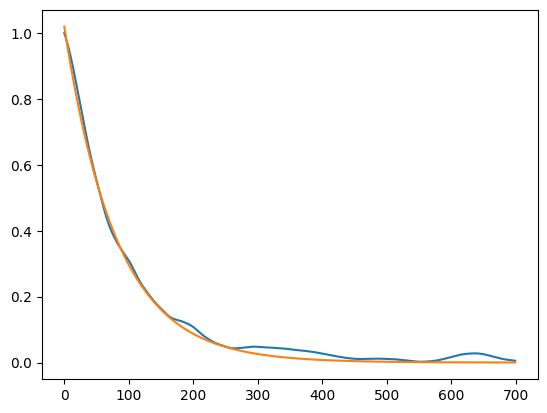

In [114]:
j = 84
x_reconstr = y_param_pred[j,0]*np.exp(-np.arange(700)/y_param_pred[j,2]) + \
             y_param_pred[j,1]*np.exp(-np.arange(700)/y_param_pred[j,3])

plt.plot(Xval[j].squeeze().detach().cpu().numpy())
plt.plot(x_reconstr);

In [115]:
Xtest = torch.Tensor(np.array(test_DWT_df)).to(device)
headlessmodel.eval()
with torch.no_grad():
    pre_outcome_val = headlessmodel(Xtest)
    outp1_val = nn.Sigmoid()(pre_outcome_val[:,:2])
    outp2_val = nn.ReLU()   (pre_outcome_val[:,2:])
    y_param_testpred = torch.cat([outp1_val,outp2_val],dim=1).squeeze().detach().cpu().numpy()
 
ytest_predPINN = y_param_testpred[:,0]/(y_param_testpred[:,0]+y_param_testpred[:,1])

## Salvando resultados
output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
output_df['%'] = ytest_predPINN
output_df.to_csv("submission/time2_trilha1_pred_PINN.csv", sep="\t", index=False)
print("csv saved");

csv saved


### Ensemble simples dos modelos: média

Realizamos um ensembling simples, com a média aritmética das saídas

RMSE: 0.093198806 R²: 0.83524984


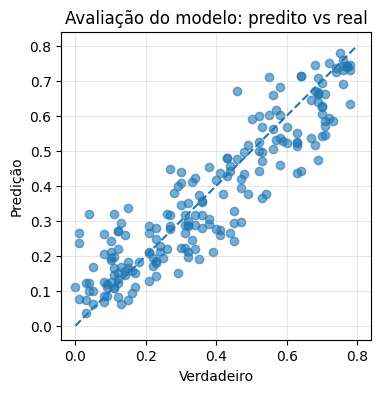

In [163]:
y_ensemble = (y_pred+y_predPINN)/2

# RMSE, R2
mse = np.mean((y_ensemble-yval)**2)
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2)

plt.figure(figsize=(4,4))
plt.scatter(yval, y_ensemble, alpha=0.6)
plt.plot([0, .8], [0, .8], '--')

plt.xlabel("Verdadeiro");plt.ylabel("Predição");plt.title(f"Avaliação do modelo: predito vs real");
plt.grid(True, alpha=0.3);plt.show();

In [164]:
ytest_ensemble = (ytest_pred+ytest_predPINN)/2
## Salvando resultados
output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
output_df['%'] = ytest_ensemble
output_df.to_csv("submission/time2_trilha1_pred_ensemble.csv", sep="\t", index=False)
print("csv saved");

csv saved
